In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## DATOS DE VIOLENCIA

In [3]:
df_violencia = pd.read_csv("./violenciaIntrafamiliar.csv")
df_violencia = df_violencia.drop_duplicates()

#castear los datos que estan como objetct a numericos
df_violencia['MES_EMISION'] = pd.to_numeric(df_violencia['MES_EMISION'], errors='coerce')
df_violencia['VIC_EDAD'] = pd.to_numeric(df_violencia['VIC_EDAD'], errors='coerce')
df_violencia['VIC_EDAD'] = df_violencia['VIC_EDAD'].fillna(df_violencia['VIC_EDAD'].mean())
df_violencia['HEC_DIA'] = pd.to_numeric(df_violencia['HEC_DIA'], errors='coerce')
df_violencia['HEC_ANO'] = pd.to_numeric(df_violencia['HEC_ANO'], errors='coerce')
df_violencia['TOTAL_HIJOS'] = pd.to_numeric(df_violencia['TOTAL_HIJOS'], errors='coerce')
df_violencia['AGR_EDAD'] = df_violencia['AGR_EDAD'].replace("ignorado", np.nan)
df_violencia['AGR_EDAD'] = pd.to_numeric(df_violencia['AGR_EDAD'], errors='coerce')
df_violencia['AGR_EDAD'] = df_violencia['AGR_EDAD'].fillna(df_violencia['AGR_EDAD'].mean())
columns_to_clean = [
	"MES_EMISION", "DEPTO_MCPIO", "QUIEN_REPORTA", "VIC_SEXO", "VIC_EST_CIV",
	"VIC_GRUPET", "VIC_NACIONAL", "VIC_DISC", "VIC_REL_AGR", "OTRAS_VICTIMAS",
	"VIC_OTRAS_HOM", "VIC_OTRAS_MUJ", "VIC_OTRAS_N_OS", "VIC_OTRAS_N_AS",
	"HEC_MES", "HEC_AREA", "HEC_TIPAGRE", "HEC_RECUR_DENUN",
	"AGR_SEXO", "AGR_ALFAB", "AGR_NACIONAL", "AGR_TRABAJA", "INST_DENUN_HECHO"
] 

for col in columns_to_clean:
	if col in df_violencia.columns:
		df_violencia[col] = df_violencia[col].astype(str).str.strip().str.lower()
		
#convertir ninguna a 0
df_violencia['OTRAS_VICTIMAS'] = df_violencia['OTRAS_VICTIMAS'].replace({"ninguna": 0})
df_violencia['VIC_OTRAS_HOM'] = df_violencia['VIC_OTRAS_HOM'].replace({"ninguno": 0})
df_violencia['VIC_OTRAS_MUJ'] = df_violencia['VIC_OTRAS_MUJ'].replace({"ninguna": 0})
df_violencia['VIC_OTRAS_N_OS'] = df_violencia['VIC_OTRAS_N_OS'].replace({"ninguna": 0})
df_violencia['VIC_OTRAS_N_AS'] = df_violencia['VIC_OTRAS_N_AS'].replace({"ninguno": 0})

#convertir ignorado a la media
df_violencia['TOTAL_HIJOS'] = df_violencia['TOTAL_HIJOS'].fillna(df_violencia['TOTAL_HIJOS'].mean())
df_violencia['VIC_OTRAS_HOM'] = df_violencia['VIC_OTRAS_HOM'].fillna(df_violencia['TOTAL_HIJOS'].mean())
df_violencia['VIC_OTRAS_MUJ'] = df_violencia['VIC_OTRAS_MUJ'].fillna(df_violencia['TOTAL_HIJOS'].mean())
df_violencia['VIC_OTRAS_N_OS'] = df_violencia['VIC_OTRAS_N_OS'].fillna(df_violencia['TOTAL_HIJOS'].mean())
df_violencia['VIC_OTRAS_N_AS'] = df_violencia['VIC_OTRAS_N_AS'].fillna(df_violencia['TOTAL_HIJOS'].mean())

#convertir a numerico
df_violencia['OTRAS_VICTIMAS'] = pd.to_numeric(df_violencia['OTRAS_VICTIMAS'], errors='coerce')
df_violencia['VIC_OTRAS_HOM'] = pd.to_numeric(df_violencia['VIC_OTRAS_HOM'], errors='coerce')
df_violencia['VIC_OTRAS_MUJ'] = pd.to_numeric(df_violencia['VIC_OTRAS_MUJ'], errors='coerce')
df_violencia['VIC_OTRAS_N_OS'] = pd.to_numeric(df_violencia['VIC_OTRAS_N_OS'], errors='coerce')
df_violencia['VIC_OTRAS_N_AS'] = pd.to_numeric(df_violencia['VIC_OTRAS_N_AS'], errors='coerce')

df_violencia.shape

C:\Users\Francis\AppData\Local\Temp\ipykernel_6808\3962652492.py:1: DtypeWarning: Columns (3,6,7,26,28,29,39,46,47,48,49,50,51,52,53,56,57,58,59,60,61,62,63,64,65,66,67,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df_violencia = pd.read_csv("./violenciaIntrafamiliar.csv")


(423630, 75)

## DATOS DE MATRIMONIO

In [4]:
df_matri = pd.read_csv("matrimonios.csv") 
columnas_validas = ['DEPREG','MUPREG','MESREG','AÑOREG','CLAUNI','EDADHOM','EDADMUJ','GETHOM','GETMUJ','NACHOM','NACMUJ','OCUHOM','OCUMUJ','NUPHON','NUPMUJ','DEPOCU','MUPOCU','MESOCU','AÑOOCU','AREAG']
df_matri = df_matri[columnas_validas]

# Eliminar datos vacios
cols_a_imputar = ["EDADHOM", "EDADMUJ", "NUPHON", "NUPMUJ"]
df_matri[cols_a_imputar] = df_matri[cols_a_imputar].replace("Ignorado", np.nan)
df_matri[cols_a_imputar] = df_matri[cols_a_imputar].apply(pd.to_numeric, errors="coerce")

df_matri.fillna({
    "MUPREG": "Ignorado",
    "MESREG": "Ignorado",
    "CLAUNI": "Ignorado",
    "GETHOM": "Ignorado",
    "GETMUJ": "Ignorado",
    "DEPREG": "Ignorado",
    "NACHOM": "Ignorado",
    "NACMUJ": "Ignorado",
    "OCUHOM": "Ignorado",
    "OCUMUJ": "Ignorado",
    "DEPOCU": "Ignorado",
    "MUPOCU": "Ignorado",
    "MESOCU": "Ignorado",
    "AREAG": "Ignorado"
}, inplace=True)

df_matri.fillna({
    "AÑOREG": df_matri["AÑOREG"].median(),
    "EDADHOM": df_matri["EDADHOM"].median(), 
    "EDADMUJ": df_matri["EDADMUJ"].median(),
    "NUPHON": df_matri["NUPHON"].median(),
    "NUPMUJ": df_matri["NUPMUJ"].median(), 
    "AÑOOCU": df_matri["AÑOOCU"].median()
}, inplace=True)

# Convertir todo a minúsculas y quitar espacios extra
df_matri["GETHOM"] = df_matri["GETHOM"].str.strip().str.lower()
df_matri["GETMUJ"] = df_matri["GETMUJ"].str.strip().str.lower()

df_matri.shape

C:\Users\Francis\AppData\Local\Temp\ipykernel_6808\890111105.py:1: DtypeWarning: Columns (0,1,2,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20,21,22,24,25,26,27,28,29,30,31,32,33,34,35,36,38,40,41,42,44,45,46,47,48,49,50) have mixed types. Specify dtype option on import or set low_memory=False.
  df_matri = pd.read_csv("matrimonios.csv")


(974972, 20)

## Igualar variables

In [5]:
# Matrimonios
['DEPREG', 'MUPREG', 'EDADHOM', 'EDADMUJ', 'GETHOM', 'GETMUJ', 
 'NACHOM', 'NACMUJ', 'OCUHOM', 'OCUMUJ', 'DEPOCU', 'MUPOCU', 'AREAG']

# Violencia
['DEPTO_MCPIO', 'VIC_SEXO', 'VIC_EDAD', 'AGR_SEXO', 'AGR_EDAD', 'VIC_GRUPET', 'AGR_GRUPET',
 'VIC_NACIONAL', 'AGR_NACIONAL', 'VIC_OCUP', 'AGR_OCUP', 'HEC_DEPTOMCPIO', 'HEC_AREA']

['DEPTO_MCPIO',
 'VIC_SEXO',
 'VIC_EDAD',
 'AGR_SEXO',
 'AGR_EDAD',
 'VIC_GRUPET',
 'AGR_GRUPET',
 'VIC_NACIONAL',
 'AGR_NACIONAL',
 'VIC_OCUP',
 'AGR_OCUP',
 'HEC_DEPTOMCPIO',
 'HEC_AREA']

### Igualar sexo

In [6]:
df_violencia['VIC_SEXO'] = df_violencia['VIC_SEXO'].replace({
    'hombres': 'hombre',
    'mujeres': 'mujer'
})

df_violencia['VIC_SEXO'].unique()

array(['mujer', 'hombre'], dtype=object)

In [7]:
df_violencia['AGR_SEXO'] = df_violencia['AGR_SEXO'].replace({
    'hombres': 'hombre',
    'mujeres': 'mujer'
})

df_violencia['AGR_SEXO'].unique()

array(['hombre', 'mujer'], dtype=object)

### Igualar edad

In [8]:
edad_hombre = df_matri['EDADHOM'].dtype
edad_mujer = df_matri['EDADMUJ'].dtype
edad_victima = df_violencia['VIC_EDAD'].dtype
edad_agresor = df_violencia['AGR_EDAD'].dtype

print(edad_hombre)
print(edad_mujer)
print(edad_victima)
print(edad_agresor)

float64
float64
float64
float64


In [9]:
df_matri['EDADHOM'] = df_matri['EDADHOM'].astype(int)
edad_hombre = df_matri['EDADHOM'].unique()
df_matri['EDADMUJ'] = df_matri['EDADMUJ'].astype(int)
edad_mujer = df_matri['EDADMUJ'].unique()
df_violencia['VIC_EDAD'] = df_violencia['VIC_EDAD'].astype(int)
edad_victima = df_violencia['VIC_EDAD'].unique()
df_violencia['AGR_EDAD'] = df_violencia['AGR_EDAD'].astype(int)
edad_agresor = df_violencia['AGR_EDAD'].unique()

print(edad_hombre)
print(edad_mujer)
print(edad_victima)
print(edad_agresor)

[16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 37 43 45 46 60
 35 36 38 39 40 47 49 41 42 55 66 44 48 50 51 57 62 65 69 53 63 71 75 54
 56 58 59 52 83 61 64 68 67 79 70 82 76 77 78 72 73 81 74 80 93 85 87 86
 84 89 88 90 92 99 91 94 95 15 14 97 96 98]
[ 14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31
  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49
  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85
  86  87  88  89 108 109  13  91  92  12  90  94  93  96  97  95  99]
[11  4  6  1 10  8  7  5  3  2  9 48 69 91 32 25 30 54 49 21 37 33 16 41
 43 19 35 15 26 29 17 31 46 28 18 50 24 38 57 22 79 53 40 14 52 23 39 60
 63 27 55 20 44 51 12 45 62 59 36 65 61 34 47 70 56 71 78 74 73 13 58 42
 68 77 83 80 75 76 67 66 64 72 88 85 87 81 92 84 89 86 82 94 90 96 93 95
 97]
[58 27 35 31 65 60 38 28 19 26 25 30 34 44 29 39 32 16 22 21 18 24 14 41
 33 4

In [10]:
df_violencia['VIC_EDADMUJ'] = np.where(df_violencia['VIC_SEXO'] == 'mujer', df_violencia['VIC_EDAD'], np.nan)
df_violencia['VIC_EDADHOM'] = np.where(df_violencia['VIC_SEXO'] == 'hombre', df_violencia['VIC_EDAD'], np.nan)
df_violencia['AGR_EDADMUJ'] = np.where(df_violencia['AGR_SEXO'] == 'mujer', df_violencia['AGR_EDAD'], np.nan)
df_violencia['AGR_EDADHOM'] = np.where(df_violencia['AGR_SEXO'] == 'hombre', df_violencia['AGR_EDAD'], np.nan)

df_violencia[['VIC_EDADMUJ', 'VIC_EDADHOM', 'AGR_EDADMUJ', 'AGR_EDADHOM']].count()

VIC_EDADMUJ    378554
VIC_EDADHOM     45076
AGR_EDADMUJ     55247
AGR_EDADHOM    368383
dtype: int64

### Igualar etnia

In [11]:
df_matri['GETHOM'].unique()

array(['indigena', 'ignorado', 'no indigena'], dtype=object)

In [12]:
df_matri['GETMUJ'].unique()

array(['indigena', 'ignorado', 'no indigena'], dtype=object)

In [13]:
df_violencia['VIC_GRUPET'].unique()

array(['ladinos(as)', 'ignorado', 'mayas', 'no indica', 'otros', 'xincas',
       'garifunas', 'xinkas', 'maya', 'otro', 'garifuna', 'xinka',
       'xinca'], dtype=object)

In [14]:
df_violencia['VIC_GRUPET'] = df_violencia['VIC_GRUPET'].replace({
    'ladinos(as)': 'ladino',
    'mayas': 'maya',
    'garifunas': 'garifuna',
    'xincas': 'xinka',
    'xinkas': 'xinka',
    'xinca': 'xinka',
    'no indica': 'ignorado',
    'otros': 'otro'
})

df_violencia['VIC_GRUPET'].unique()

array(['ladino', 'ignorado', 'maya', 'otro', 'xinka', 'garifuna'],
      dtype=object)

In [15]:
df_violencia['VIC_GRUPET'] = df_violencia['VIC_GRUPET'].replace({
    'ladino': 'no indigena',
    'maya': 'indigena',
    'garifuna': 'indigena',
    'xinka': 'indigena',
    'otro': 'no indigena'
})

df_violencia['VIC_GRUPET'].unique()

array(['no indigena', 'ignorado', 'indigena'], dtype=object)

In [16]:
df_violencia['AGR_GRUPET'].unique()

array([nan, 'Ladinos(as)', 'Mayas', 'Ignorado', 'No indica', 'Otros',
       'Xinkas', 'Garifunas', 'Maya', 'Otro', 'Xinka', 'Garifuna'],
      dtype=object)

In [17]:
df_violencia["AGR_GRUPET"] = df_violencia["AGR_GRUPET"].str.strip().str.lower()

In [18]:
df_violencia['AGR_GRUPET'] = df_violencia['AGR_GRUPET'].replace({
    'ladinos(as)': 'ladino',
    'mayas': 'maya',
    'garifunas': 'garifuna',
    'xinkas': 'xinka',
    'no indica': 'ignorado',
    'otros': 'otro'
})

df_violencia.fillna({"AGR_GRUPET": "ignorado"}, inplace=True)



In [19]:
df_violencia['AGR_GRUPET'] = df_violencia['AGR_GRUPET'].replace({
    'ladino': 'no indigena',
    'maya': 'indigena',
    'garifuna': 'indigena',
    'xinka': 'indigena',
    'otro': 'no indigena'
})

In [20]:
df_violencia['AGR_GRUPET'].unique()

array(['ignorado', 'no indigena', 'indigena'], dtype=object)

### Igualar nacionalidad

In [21]:
nac_hom = df_matri['NACHOM'].unique()
nac_muj = df_matri['NACMUJ'].unique()
nac_vic = df_violencia['VIC_NACIONAL'].unique()
nac_agr = df_violencia['AGR_NACIONAL'].unique()

print(f"Nacionalidad hombre:\n{nac_hom}")
print(f"Nacionalidad mujer:\n{nac_muj}")
print(f"Nacionalidad victima:\n{nac_vic}")
print(f"Nacionalidad agresor:\n{nac_agr}")

Nacionalidad hombre:
['Guatemala' 'México' 'Estados Unidos de América' 'Nicaragua'
 'El Salvador' 'Ignorado' 'Honduras' 'Canadá' 'Argentina' 'Cuba' 'Suecia'
 'Chile' 'Costa Rica' 'España' 'Colombia' 'Puerto Rico e Islas Vírgenes'
 'República Dominicana' 'Gran Bretaña'
 'Dinamarca, Checoslovaquia, Polonia, Bélgica, Inglaterra)'
 'Otros Países (Grecia, Austria, Rumania, Viena, Noruega,' 'Perú'
 'Otros Países (Hong Kong, Rusia,' 'Bolivia' 'Otros (Trinidad y Tobago)'
 'Venezuela' 'India' 'Francia' 'Alemania' 'Panamá y Zona del Canal'
 'Japón' 'Italia' 'Suiza' 'Otros (Paraguay y Uruguay)' 'Ecuador' 'Belice'
 'Jordania, Hawaii, Singapore, Vietnam, Korea)' 'Africa'
 'Israel (Jerusalén)' 'Holanda' 'Filipinas' 'Jamaica' 'Australia'
 'Zimbawe del Norte' 'República de Libano' 'Israel' 'Bélgica' 'Austria'
 'Brasil' 'Irlanda' 'Uruguay' 'Turquia' 'Croacia' 'Noruega' 'Jordania'
 'Puerto Rico' 'Rusia' 'China' 'Corea Del Sur' 'Siria'
 'República de China (Taiwan)' 'Rumania' 'Paraguay' 'Bahamas' 'Libano

In [22]:
def clasificar_nacionalidad(valor):
    if pd.isna(valor):
        return 'ignorado'
    valor = valor.strip().lower()
    if valor == 'guatemala':
        return 'guatemalteca'
    elif 'ignorado' in valor:
        return 'ignorado'
    else:
        return 'extranjera'

df_matri['NACHOM'] = df_matri['NACHOM'].apply(clasificar_nacionalidad)
df_matri['NACMUJ'] = df_matri['NACMUJ'].apply(clasificar_nacionalidad)

### Igualar ocupación

In [23]:
# Filtrar solo los casos confirmados como conducente
df_violencia['CONDUCENTE'] = df_violencia['CONDUCENTE'].replace({2.0: 0, 9.0: 0})

conducente1 = df_violencia[df_violencia['CONDUCENTE'] == 1]


Frecuencia de VIC_OCUP:
VIC_OCUP
Vendedores no clasificados bajo otros epígrafes                                    15.262829
Limpiadores y asistentes domésticos                                                14.005006
Maestros de enseñanza primaria                                                      6.326658
Agricultores y trabajadores calificados de cultivos extensivos                      5.707134
Ocupaciones no especificadas en las anteriores                                      4.036295
                                                                                     ...    
Practicantes y asistentes médicos                                                   0.006258
Vendedores por teléfono                                                             0.006258
Empleados de agencias de viajes                                                     0.006258
Programadores de aplicaciones                                                       0.006258
Instaladores y reparadores en tecnolo

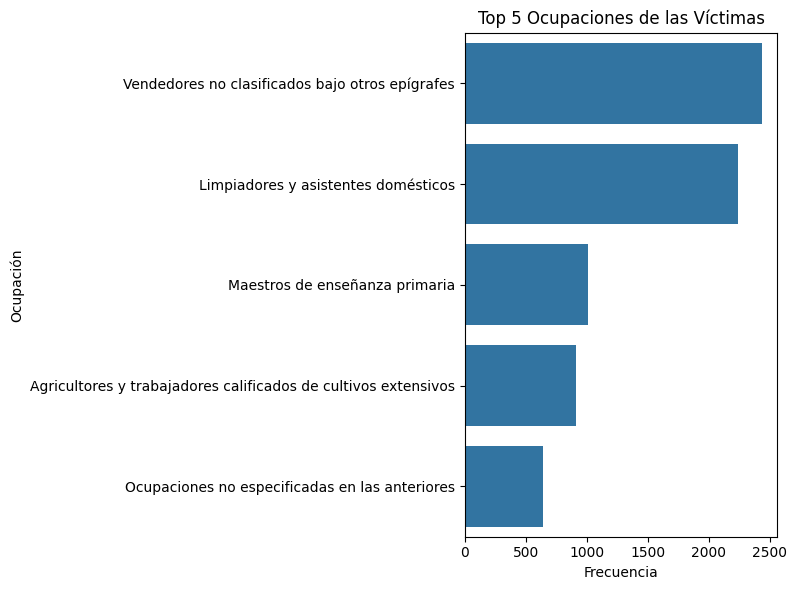

In [24]:
print("Frecuencia de VIC_OCUP:")
print(conducente1['VIC_OCUP'].value_counts(normalize=True) * 100)


top_5_ocupaciones = conducente1['VIC_OCUP'].value_counts().nlargest(5).index

# Graficar
plt.figure(figsize=(8, 6))
sns.countplot(y=conducente1['VIC_OCUP'], order=top_5_ocupaciones)
plt.title("Top 5 Ocupaciones de las Víctimas")
plt.xlabel("Frecuencia")
plt.ylabel("Ocupación")
plt.tight_layout()
plt.show()

Frecuencia de AGR_OCUP:
AGR_OCUP
Agricultores y trabajadores calificados de cultivos extensivos                                                 23.671623
Peones de explotaciones agrícolas                                                                              16.967883
Vendedores no clasificados bajo otros epígrafes                                                                10.061500
Ocupaciones ignoradas                                                                                           7.627418
Albañiles                                                                                                       4.641957
                                                                                                                 ...    
Analistas de gestión y organización                                                                             0.002356
Técnicos en ciencias biológicas (excluyendo la medicina)                                                        0.002356

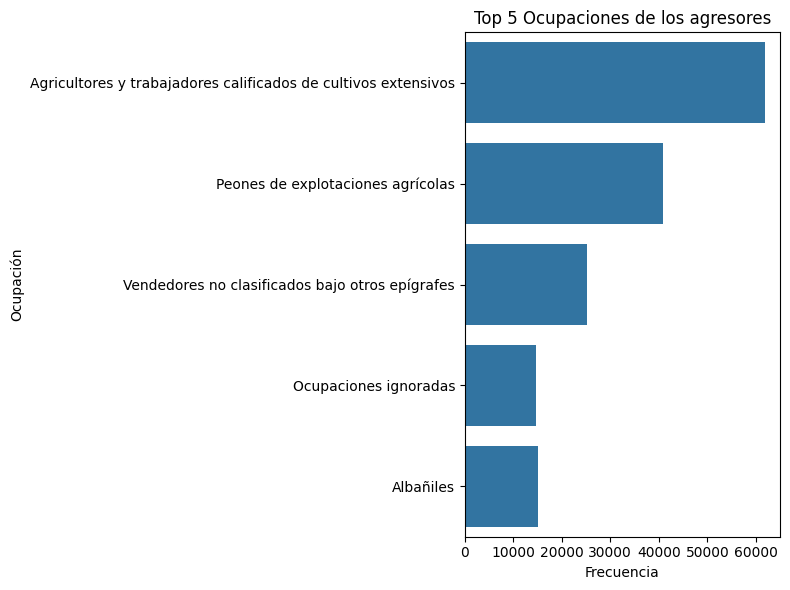

In [25]:
print("Frecuencia de AGR_OCUP:")
print(conducente1['AGR_OCUP'].value_counts(normalize=True) * 100)


top_5_ocupaciones = conducente1['AGR_OCUP'].value_counts().nlargest(5).index

# Graficar
plt.figure(figsize=(8, 6))
sns.countplot(y=df_violencia['AGR_OCUP'], order=top_5_ocupaciones)
plt.title("Top 5 Ocupaciones de los agresores")
plt.xlabel("Frecuencia")
plt.ylabel("Ocupación")
plt.tight_layout()
plt.show()

Frecuencia de AGR_DEDICA:
AGR_DEDICA
Quehaceres del Hogar              44.700845
Ignorado                          33.805162
Desempleado                       10.098727
Estudiar                           5.626264
Vive de sus Renta o Jubilación     3.960985
Otro                               1.617700
Alcohólico/Drogadicto              0.190318
Name: proportion, dtype: float64


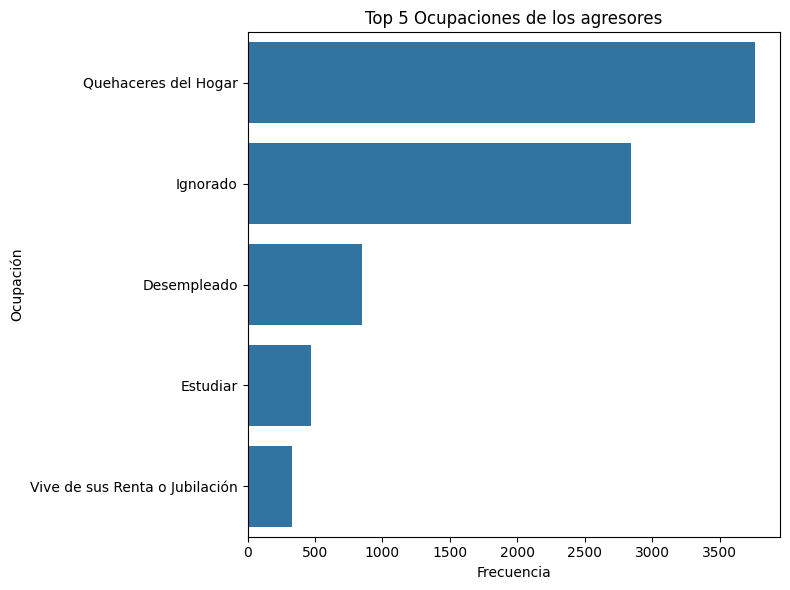

In [26]:
print("Frecuencia de AGR_DEDICA:")
print(conducente1['AGR_DEDICA'].value_counts(normalize=True) * 100)


top_5_ocupaciones = conducente1['AGR_DEDICA'].value_counts().nlargest(5).index

# Graficar
plt.figure(figsize=(8, 6))
sns.countplot(y=conducente1['AGR_DEDICA'], order=top_5_ocupaciones)
plt.title("Top 5 Ocupaciones de los agresores")
plt.xlabel("Frecuencia")
plt.ylabel("Ocupación")
plt.tight_layout()
plt.show()

Frecuencia de VIC_DEDICA:
VIC_DEDICA
Quehaceres del hogar              94.319384
Estudiar                           2.944634
Ignorado                           1.313624
Vive de sus renta o jubilación     1.005055
Desempleado                        0.252733
Otro                               0.158693
Alcohólico/drogadicto              0.005878
Name: proportion, dtype: float64


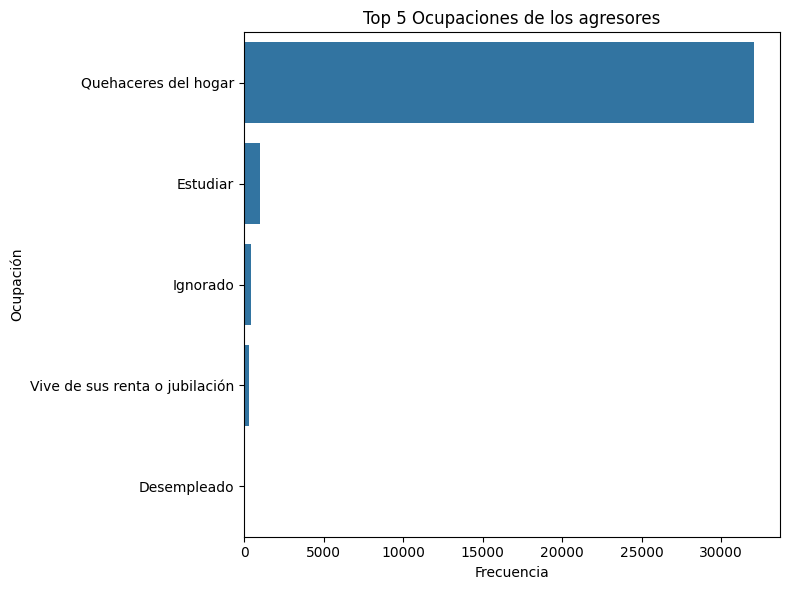

In [27]:
print("Frecuencia de VIC_DEDICA:")
print(conducente1['VIC_DEDICA'].value_counts(normalize=True) * 100)


top_5_ocupaciones = conducente1['VIC_DEDICA'].value_counts().nlargest(5).index

# Graficar
plt.figure(figsize=(8, 6))
sns.countplot(y=conducente1['VIC_DEDICA'], order=top_5_ocupaciones)
plt.title("Top 5 Ocupaciones de los agresores")
plt.xlabel("Frecuencia")
plt.ylabel("Ocupación")
plt.tight_layout()
plt.show()

### Igualar departamentos / municipios

In [28]:
depto_muni_rep = df_violencia['DEPTO_MCPIO'].unique()
depto_muni_hech = df_violencia['HEC_DEPTOMCPIO'].unique()
muni_ocu = df_matri['MUPOCU'].unique()
dep_ocu = df_matri['DEPOCU'].unique()
dep_reg = df_matri['DEPREG'].unique()
muni_reg = df_matri['MUPREG'].unique()

print(f"Municipio reporte\n{depto_muni_rep}")
print(f"Municipio hecho\n{depto_muni_hech}")
print(f"Municipio registro\n{muni_reg}")
print(f"Departamento registro\n{dep_reg}")
print(f"Municipio ocurrencia\n{muni_ocu}")
print(f"Departamento ocurrencia\n{dep_ocu}")


Municipio reporte
['guatemala' 'guastatoya' 'san cristóbal acasaguastlán' 'sansare'
 'san marcos' 'cubulco' 'poptún' 'mazatenango' 'villa canales' 'escuintla'
 'retalhuleu' 'zacapa' 'san rafael las flores' 'sololá' 'san felipe'
 'gualán' 'pastores' 'tucurú' 'jocotán' 'san pedro pinula' 'mixco'
 'momostenango' 'chiquimula' 'san lorenzo' 'cobán' 'morales' 'comalapa'
 'taxisco' 'san andrés semetabaj' 'samayac' 'uspantán' 'purulhá'
 'el jícaro' 'san lucas toliman' 'quetzaltenango'
 'santo domingo suchitepéquez' 'san juan erminta' 'san josé el golfo'
 'san pablo la laguna' 'villa nueva' 'quesada' 'zunilito' 'jalapa'
 'chinautla' 'san pedro sacatepéquez' 'san juan sacatepéquez' 'morazán'
 'san agustín acasaguastlán' 'sanarate' 'jocotenango' 'antigua guatemala'
 'san lucas sacatepéquez' 'santa catarina barahona' 'chimaltenango'
 'san josé poaquil' 'san martín jilotepeque' 'tecpán guatemala' 'yepocapa'
 'tiquisate' 'palín' 'barberena' 'casillas' 'oratorio'
 'santa maría ixhuatán' 'pueblo nuevo

In [29]:
df_matri['MUPOCU'] = df_matri['MUPOCU'].astype(str).str.strip().str.lower()
df_matri['DEPOCU'] = df_matri['DEPOCU'].astype(str).str.strip().str.lower()
df_matri['DEPREG'] = df_matri['DEPREG'].astype(str).str.strip().str.lower()
df_matri['MUPREG'] = df_matri['MUPREG'].astype(str).str.strip().str.lower()
df_violencia['HEC_DEPTOMCPIO'] = df_violencia['HEC_DEPTOMCPIO'].astype(str).str.strip().str.lower()
df_violencia = df_violencia.rename(columns={'HEC_DEPTOMCPIO': 'HEC_MUNI', 'DEPTO_MCPIO': 'REP_MUNI'})

In [30]:
import re

df_violencia['REP_MUNI'] = df_violencia['REP_MUNI'].apply(
    lambda x: "ignorado" if pd.to_numeric(x, errors='coerce') is not pd.NA and not pd.isna(pd.to_numeric(x, errors='coerce')) else x
)
df_violencia['HEC_MUNI'] = df_violencia['HEC_MUNI'].apply(
    lambda x: "ignorado" if pd.to_numeric(x, errors='coerce') is not pd.NA and not pd.isna(pd.to_numeric(x, errors='coerce')) else x
)
df_matri['MUPOCU'] = df_matri['MUPOCU'].apply(
    lambda x: "ignorado" if re.fullmatch(r'[\d\.-]+', str(x)) else x
)


In [31]:
mupocu_dict = df_matri.set_index('MUPOCU')['DEPOCU'].to_dict()

def obtener_departamento(muni):
    if muni == "ignorado":
        return "ignorado"
    return mupocu_dict.get(muni, "ignorado")

df_violencia['REP_DEP'] = df_violencia['REP_MUNI'].apply(obtener_departamento)
df_violencia['HEC_DEP'] = df_violencia['HEC_MUNI'].apply(obtener_departamento)



In [32]:
depto_muni_rep = df_violencia['REP_MUNI'].unique()
depto_muni_hech = df_violencia['HEC_MUNI'].unique()
muni_ocu = df_matri['MUPOCU'].unique()
dep_ocu = df_matri['DEPOCU'].unique()
dep_reg = df_matri['DEPREG'].unique()
muni_reg = df_matri['MUPREG'].unique()
dep_rep = df_violencia['REP_DEP'].unique()
dep_hech = df_violencia['HEC_DEP'].unique()

print(f"Municipio reporte\n{depto_muni_rep}")
print(f"Departamento reporte\n{dep_rep}")
print(f"Municipio hecho\n{depto_muni_hech}")
print(f"Departamento hecho\n{dep_hech}")
print(f"Municipio registro\n{muni_reg}")
print(f"Departamento registro\n{dep_reg}")
print(f"Municipio ocurrencia\n{muni_ocu}")
print(f"Departamento ocurrencia\n{dep_ocu}")

Municipio reporte
['guatemala' 'guastatoya' 'san cristóbal acasaguastlán' 'sansare'
 'san marcos' 'cubulco' 'poptún' 'mazatenango' 'villa canales' 'escuintla'
 'retalhuleu' 'zacapa' 'san rafael las flores' 'sololá' 'san felipe'
 'gualán' 'pastores' 'tucurú' 'jocotán' 'san pedro pinula' 'mixco'
 'momostenango' 'chiquimula' 'san lorenzo' 'cobán' 'morales' 'comalapa'
 'taxisco' 'san andrés semetabaj' 'samayac' 'uspantán' 'purulhá'
 'el jícaro' 'san lucas toliman' 'quetzaltenango'
 'santo domingo suchitepéquez' 'san juan erminta' 'san josé el golfo'
 'san pablo la laguna' 'villa nueva' 'quesada' 'zunilito' 'jalapa'
 'chinautla' 'san pedro sacatepéquez' 'san juan sacatepéquez' 'morazán'
 'san agustín acasaguastlán' 'sanarate' 'jocotenango' 'antigua guatemala'
 'san lucas sacatepéquez' 'santa catarina barahona' 'chimaltenango'
 'san josé poaquil' 'san martín jilotepeque' 'tecpán guatemala' 'yepocapa'
 'tiquisate' 'palín' 'barberena' 'casillas' 'oratorio'
 'santa maría ixhuatán' 'pueblo nuevo

### Igualar área geográfica

In [33]:
df_matri['AREAG'] = df_matri['AREAG'].astype(str).str.strip().str.lower()
df_matri['AREAG'] = df_matri['AREAG'].replace({
    'urbano': 'urbana'
})
area_matri = df_matri['AREAG'].unique()

area_violencia = df_violencia['HEC_AREA'].unique()

print(area_matri)
print(area_violencia)

['ignorado' 'urbana' 'rural']
['urbana' 'ignorado' 'rural']


## Resultados

In [34]:
df_violencia['VIC_REL_AGR'].unique()

array(['hijos(as)', 'nietos(as)', 'hijastros(as)', 'otro pariente',
       'hermanos(as)', 'esposos(as)', 'padres/madres', 'ex-cónyuges',
       'conviviente', 'suegros(as)', 'esposos(a)'], dtype=object)

In [35]:
df_violencia = df_violencia[(df_violencia['ANO_EMISION'] >= 2017) & (df_violencia['VIC_REL_AGR'] == 'esposos(a)')]

df_violencia[['REP_DEP', 'REP_MUNI', 'VIC_SEXO', 'VIC_EDAD', 'AGR_SEXO', 'AGR_EDAD', 'VIC_GRUPET', 'AGR_GRUPET','VIC_NACIONAL', 'AGR_NACIONAL', 'VIC_OCUP', 'AGR_OCUP', 'HEC_DEP', 'HEC_MUNI', 'HEC_AREA', 'VIC_EDADMUJ', 'VIC_EDADHOM', 'AGR_EDADMUJ', 'AGR_EDADHOM']].head()

,REP_DEP,REP_MUNI,VIC_SEXO,VIC_EDAD,AGR_SEXO,AGR_EDAD,VIC_GRUPET,AGR_GRUPET,VIC_NACIONAL,AGR_NACIONAL,VIC_OCUP,AGR_OCUP,HEC_DEP,HEC_MUNI,HEC_AREA,VIC_EDADMUJ,VIC_EDADHOM,AGR_EDADMUJ,AGR_EDADHOM
266725,ignorado,ignorado,mujer,31,hombre,39,no indigena,ignorado,guatemalteca,guatemalteca,Conserjes,Declarantes o gestores de aduana,ignorado,ignorado,urbana,31.0,NaN,NaN,39.0
266726,ignorado,ignorado,mujer,31,hombre,35,no indigena,ignorado,guatemalteca,guatemalteca,Vendedores no clasificados bajo otros epígrafes,Prestamistas,ignorado,ignorado,urbana,31.0,NaN,NaN,35.0
266733,ignorado,ignorado,mujer,54,hombre,55,no indigena,ignorado,guatemalteca,guatemalteca,Profesionales en derecho no clasificados bajo ...,NaN,ignorado,ignorado,urbana,54.0,NaN,NaN,55.0
266737,ignorado,ignorado,mujer,33,hombre,36,no indigena,ignorado,guatemalteca,guatemalteca,Ocupaciones no especificadas en las anteriores,Supervisores de tiendas y almacenes,ignorado,ignorado,urbana,33.0,NaN,NaN,36.0
266742,ignorado,ignorado,mujer,28,hombre,25,no indigena,ignorado,guatemalteca,guatemalteca,NaN,Secretarios (general),ignorado,ignorado,urbana,28.0,NaN,NaN,25.0


In [36]:
df_violencia.tail()

,ANO_EMISION,MES_EMISION,DIA_EMISION,REP_MUNI,QUIEN_REPORTA,VIC_SEXO,VIC_EDAD,TOTAL_HIJOS,NUM_HIJ_HOM,NUM_HIJ_MUJ,...,ARTICULOTRAS4,ORGANISMO_REMITE,filter_$,NUMERO_BOLETA,VIC_EDADMUJ,VIC_EDADHOM,AGR_EDADMUJ,AGR_EDADHOM,REP_DEP,HEC_DEP
423629,2021.0,nan,27.0,ignorado,víctima,mujer,50,12.0000,08,04,...,NaN,NaN,NaN,48.0,50.0,NaN,NaN,56.0,ignorado,ignorado
423631,2021.0,nan,19.0,ignorado,víctima,mujer,27,5.0000,05,Ninguna,...,NaN,NaN,NaN,50.0,27.0,NaN,NaN,29.0,ignorado,ignorado
423633,2021.0,nan,10.0,ignorado,víctima,mujer,33,1.0000,01,Ninguna,...,NaN,1.0,NaN,52.0,33.0,NaN,NaN,30.0,ignorado,ignorado
423634,2021.0,nan,13.0,ignorado,víctima,mujer,34,1.0000,01,Ninguna,...,NaN,1.0,NaN,53.0,34.0,NaN,NaN,35.0,ignorado,ignorado
423645,2021.0,nan,19.0,ignorado,víctima,mujer,23,2.5307,Ignorado,Ignorado,...,NaN,17.0,NaN,64.0,23.0,NaN,NaN,27.0,ignorado,ignorado


In [37]:
df_matri[['DEPREG', 'MUPREG', 'EDADHOM', 'EDADMUJ', 'GETHOM', 'GETMUJ', 'NACHOM', 'NACMUJ', 'OCUHOM', 'OCUMUJ', 'DEPOCU', 'MUPOCU', 'AREAG']].head()

,DEPREG,MUPREG,EDADHOM,EDADMUJ,GETHOM,GETMUJ,NACHOM,NACMUJ,OCUHOM,OCUMUJ,DEPOCU,MUPOCU,AREAG
0,san marcos,comitancillo,16,14,indigena,indigena,guatemalteca,guatemalteca,Ignorado,Ignorado,san marcos,comitancillo,ignorado
1,retalhuleu,retalhuleu,16,14,ignorado,ignorado,guatemalteca,guatemalteca,Agricultores y trabajadores calificados de cul...,Oficios domésticos no remunerados,retalhuleu,retalhuleu,ignorado
2,huehuetenango,chiantla,16,14,ignorado,ignorado,guatemalteca,guatemalteca,Agricultores y trabajadores calificados de cul...,Oficios domésticos no remunerados,huehuetenango,chiantla,ignorado
3,quiche,joyabaj,16,14,indigena,indigena,guatemalteca,guatemalteca,Agricultores y trabajadores calificados de cul...,Oficios domésticos no remunerados,quiche,joyabaj,ignorado
4,quiche,joyabaj,16,14,indigena,indigena,guatemalteca,guatemalteca,Agricultores y trabajadores calificados de cul...,Oficios domésticos no remunerados,quiche,joyabaj,ignorado


In [38]:
df_matri.tail()

,DEPREG,MUPREG,MESREG,AÑOREG,CLAUNI,EDADHOM,EDADMUJ,GETHOM,GETMUJ,NACHOM,NACMUJ,OCUHOM,OCUMUJ,NUPHON,NUPMUJ,DEPOCU,MUPOCU,MESOCU,AÑOOCU,AREAG
974967,guatemala,villa nueva,Abril,2021.0,Comunidad de gananciales,94,54,ignorado,ignorado,guatemalteca,guatemalteca,Ignorado,Ignorado,1.0,1.0,guatemala,villa nueva,Abril,2021.0,ignorado
974968,santa rosa,taxisco,Julio,2021.0,Comunidad de gananciales,95,69,ignorado,ignorado,guatemalteca,guatemalteca,Ignorado,Ignorado,1.0,1.0,santa rosa,taxisco,Julio,2021.0,ignorado
974969,suchitepéquez,san francisco zapotitlán,Agosto,2021.0,Comunidad de gananciales,95,69,ignorado,ignorado,guatemalteca,guatemalteca,Ignorado,Ignorado,1.0,1.0,escuintla,nueva concepción,Junio,2021.0,ignorado
974970,guatemala,guatemala,Octubre,2021.0,Comunidad absoluta,98,72,ignorado,ignorado,guatemalteca,guatemalteca,Ignorado,Ignorado,1.0,1.0,guatemala,guatemala,Septiembre,2021.0,ignorado
974971,guatemala,guatemala,Febrero,2022.0,Comunidad de gananciales,99,71,ignorado,ignorado,guatemalteca,guatemalteca,Ignorado,Ignorado,1.0,1.0,guatemala,guatemala,Noviembre,2021.0,ignorado


In [39]:
print(df_violencia.info())

<class 'pandas.core.frame.DataFrame'>
Index: 43145 entries, 266725 to 423645
Data columns (total 81 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ANO_EMISION               43145 non-null  float64
 1   MES_EMISION               43145 non-null  object 
 2   DIA_EMISION               43145 non-null  float64
 3   REP_MUNI                  43145 non-null  object 
 4   QUIEN_REPORTA             43145 non-null  object 
 5   VIC_SEXO                  43145 non-null  object 
 6   VIC_EDAD                  43145 non-null  int64  
 7   TOTAL_HIJOS               43145 non-null  float64
 8   NUM_HIJ_HOM               43145 non-null  object 
 9   NUM_HIJ_MUJ               43145 non-null  object 
 10  VIC_ALFAB                 43145 non-null  object 
 11  VIC_ESCOLARIDAD           43145 non-null  object 
 12  VIC_EST_CIV               43145 non-null  object 
 13  VIC_GRUPET                43145 non-null  object 
 14  VIC_N

In [41]:
print(df_matri.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 974972 entries, 0 to 974971
Data columns (total 20 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   DEPREG   974972 non-null  object 
 1   MUPREG   974972 non-null  object 
 2   MESREG   974972 non-null  object 
 3   AÑOREG   974972 non-null  float64
 4   CLAUNI   974972 non-null  object 
 5   EDADHOM  974972 non-null  int64  
 6   EDADMUJ  974972 non-null  int64  
 7   GETHOM   974972 non-null  object 
 8   GETMUJ   974972 non-null  object 
 9   NACHOM   974972 non-null  object 
 10  NACMUJ   974972 non-null  object 
 11  OCUHOM   974972 non-null  object 
 12  OCUMUJ   974972 non-null  object 
 13  NUPHON   974972 non-null  float64
 14  NUPMUJ   974972 non-null  float64
 15  DEPOCU   974972 non-null  object 
 16  MUPOCU   974972 non-null  object 
 17  MESOCU   974972 non-null  object 
 18  AÑOOCU   974972 non-null  float64
 19  AREAG    974972 non-null  object 
dtypes: float64(4), int64(2), o

In [ ]:
# Guardar df_matri en matri_unite_data.csv
df_matri[['DEPREG', 'MUPREG', 'EDADHOM', 'EDADMUJ', 'GETHOM', 'GETMUJ', 'NACHOM', 'NACMUJ', 'OCUHOM', 'OCUMUJ', 'DEPOCU', 'MUPOCU', 'AREAG']].to_csv('matri_unite_data.csv', index=False)

# Guardar df_violencia en violencia_unite_data.csv
df_violencia[['VIC_SEXO', 'VIC_EDAD', 'AGR_SEXO', 'AGR_EDAD', 'VIC_GRUPET', 'AGR_GRUPET','VIC_NACIONAL', 'AGR_NACIONAL', 'VIC_OCUP', 'AGR_OCUP', 'HEC_DEP', 'HEC_MUNI', 'HEC_AREA', 'VIC_EDADMUJ', 'AGR_EDADHOM', 'CONDUCENTE']].to_csv('violencia_unite_data.csv', index=False)

In [46]:
# transformación del dataset de matrimonio para que se parezca al de violencia 
import pandas as pd


df_mapeado = pd.DataFrame({
    'VIC_SEXO': 2,  # Mujer
    'VIC_EDAD': df_matri['EDADMUJ'],
    'VIC_EDADMUJ': df_matri['EDADMUJ'],
    'VIC_OCUP': df_matri['OCUMUJ'],
    'VIC_NACIONAL': df_matri['NACMUJ'],
    'VIC_GRUPET': df_matri['GETMUJ'],
    
    'AGR_SEXO': 1,  # Hombre
    'AGR_EDAD': df_matri['EDADHOM'],
    'AGR_EDADHOM':df_matri['EDADHOM'],
    'AGR_OCUP': df_matri['OCUHOM'],
    'AGR_NACIONAL': df_matri['NACHOM'],
    'AGR_GRUPET': df_matri['GETHOM'],

    'HEC_DEP': df_matri['DEPREG'],
    'HEC_MUNI': df_matri['MUPREG'],
    'HEC_AREA': df_matri['AREAG']
})


df_mapeado.to_csv('df_mapeado.csv', index=False)